# Visualization: Food Delivery Pattern Analysis

This notebook produces all network diagrams and association graphs by consuming the outputs of:
- **Member 2**: Apriori algorithm
- **Member 3**: FP-Growth algorithm
- **Member 4**: PageRank algorithm

### Visualizations produced:
1. Top 10 Frequent Itemsets + Algorithm Speed Comparison
2. Support vs Confidence scatter plot (colored by Lift)
3. Association Rules Network Graph (top rules, clean layout)
4. Association Rules Heatmap (Confidence matrix)
5. Top 15 Meals by PageRank Score
6. Meal Co-occurrence Network (PageRank-weighted)

## 1. Imports

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import ast
import itertools
import collections
import time
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('All libraries loaded.')

All libraries loaded.


## 2. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/data/final_dataset2.csv')

# Parse Items_List for transaction encoding
transactions = df['Items_List'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
).tolist()

# One-hot encode
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
encoded_df = pd.DataFrame(te_ary, columns=te.columns_)

# Parse Items column for co-occurrence graph
df['Items_Parsed'] = df['Items'].apply(
    lambda x: [item.strip() for item in str(x).split(',') if item.strip()]
)
df['Item_Count'] = df['Items_Parsed'].apply(len)

print(f'Orders loaded:      {len(df):,}')
print(f'Unique items:       {encoded_df.shape[1]}')
print(f'Unique restaurants: {df["Restaurant"].nunique()}')
print(f'Avg items/order:    {df["Item_Count"].mean():.2f}')

Orders loaded:      20,000
Unique items:       46
Unique restaurants: 10
Avg items/order:    3.89


## 3. Compute Association Rules with Timing (Apriori & FP-Growth)

In [3]:
THRESHOLDS     = [0.05, 0.1, 0.2]
MIN_CONFIDENCE = 0.4
MIN_LIFT       = 1.0
BEST_SUPPORT   = 0.05

timing_records = []
apriori_itemsets_map = {}
fpg_itemsets_map     = {}

for sup in THRESHOLDS:
    t0 = time.time()
    a_items = apriori(encoded_df, min_support=sup, use_colnames=True)
    t_apriori = time.time() - t0

    t0 = time.time()
    f_items = fpgrowth(encoded_df, min_support=sup, use_colnames=True)
    t_fpg = time.time() - t0

    apriori_itemsets_map[sup] = a_items
    fpg_itemsets_map[sup]     = f_items

    timing_records.append({'Support': sup,
                           'Apriori (s)':   round(t_apriori, 4),
                           'FP-Growth (s)': round(t_fpg,     4),
                           'Apriori itemsets':   len(a_items),
                           'FP-Growth itemsets': len(f_items)})

timing_df = pd.DataFrame(timing_records)

# Use best support for rule generation
apriori_itemsets = apriori_itemsets_map[BEST_SUPPORT]
fpg_itemsets     = fpg_itemsets_map[BEST_SUPPORT]

def get_strong_rules(itemsets):
    rules = association_rules(itemsets, metric='lift', min_threshold=MIN_LIFT)
    return rules[(rules['confidence'] > MIN_CONFIDENCE) & (rules['lift'] > MIN_LIFT)].copy()

apriori_rules = get_strong_rules(apriori_itemsets)
fpg_rules     = get_strong_rules(fpg_itemsets)

print(timing_df.to_string(index=False))
print()
print(f'Strong rules (support={BEST_SUPPORT}): Apriori={len(apriori_rules)}, FP-Growth={len(fpg_rules)}')

 Support  Apriori (s)  FP-Growth (s)  Apriori itemsets  FP-Growth itemsets
    0.05       0.0184         0.0428                41                  41
    0.10       0.0028         0.0408                 9                   9
    0.20       0.0020         0.0509                 2                   2

Strong rules (support=0.05): Apriori=16, FP-Growth=16


## 4. Build Co-occurrence Graph & Run PageRank

In [4]:
multi_item_orders = df[df['Item_Count'] >= 2]['Items_Parsed'].tolist()

co_occur = collections.Counter()
for transaction in multi_item_orders:
    # Deduplicate items within a transaction to prevent self-loops
    unique_items = sorted(set(transaction))
    for a, b in itertools.combinations(unique_items, 2):
        co_occur[(a, b)] += 1

G_meal = nx.Graph()
for (a, b), weight in co_occur.items():
    if a != b:  # extra guard against self-loops
        G_meal.add_edge(a, b, weight=weight)

pagerank_scores = nx.pagerank(G_meal, alpha=0.85, weight='weight')

pr_df = pd.DataFrame(
    list(pagerank_scores.items()), columns=['Meal', 'PageRank_Score']
).sort_values('PageRank_Score', ascending=False).reset_index(drop=True)
pr_df.index += 1

top_meal       = pr_df.iloc[0]['Meal']
top_meal_score = pr_df.iloc[0]['PageRank_Score']

print(f'Graph: {G_meal.number_of_nodes()} nodes, {G_meal.number_of_edges()} edges (self-loops removed)')
print()
print('Top 10 Meals by PageRank:')
print(pr_df.head(10).to_string())

Graph: 46 nodes, 886 edges (self-loops removed)

Top 10 Meals by PageRank:
               Meal  PageRank_Score
1             Fries        0.084159
2             Pepsi        0.050252
3             Juice        0.048284
4              Coke        0.036267
5         McChicken        0.031867
6             Wings        0.027976
7     Potato Wedges        0.027667
8      Cheesy Bread        0.027270
9   Pepperoni Pizza        0.026665
10           Zinger        0.026061


---
## Visualization 1 Frequent Itemsets & Algorithm Speed Comparison

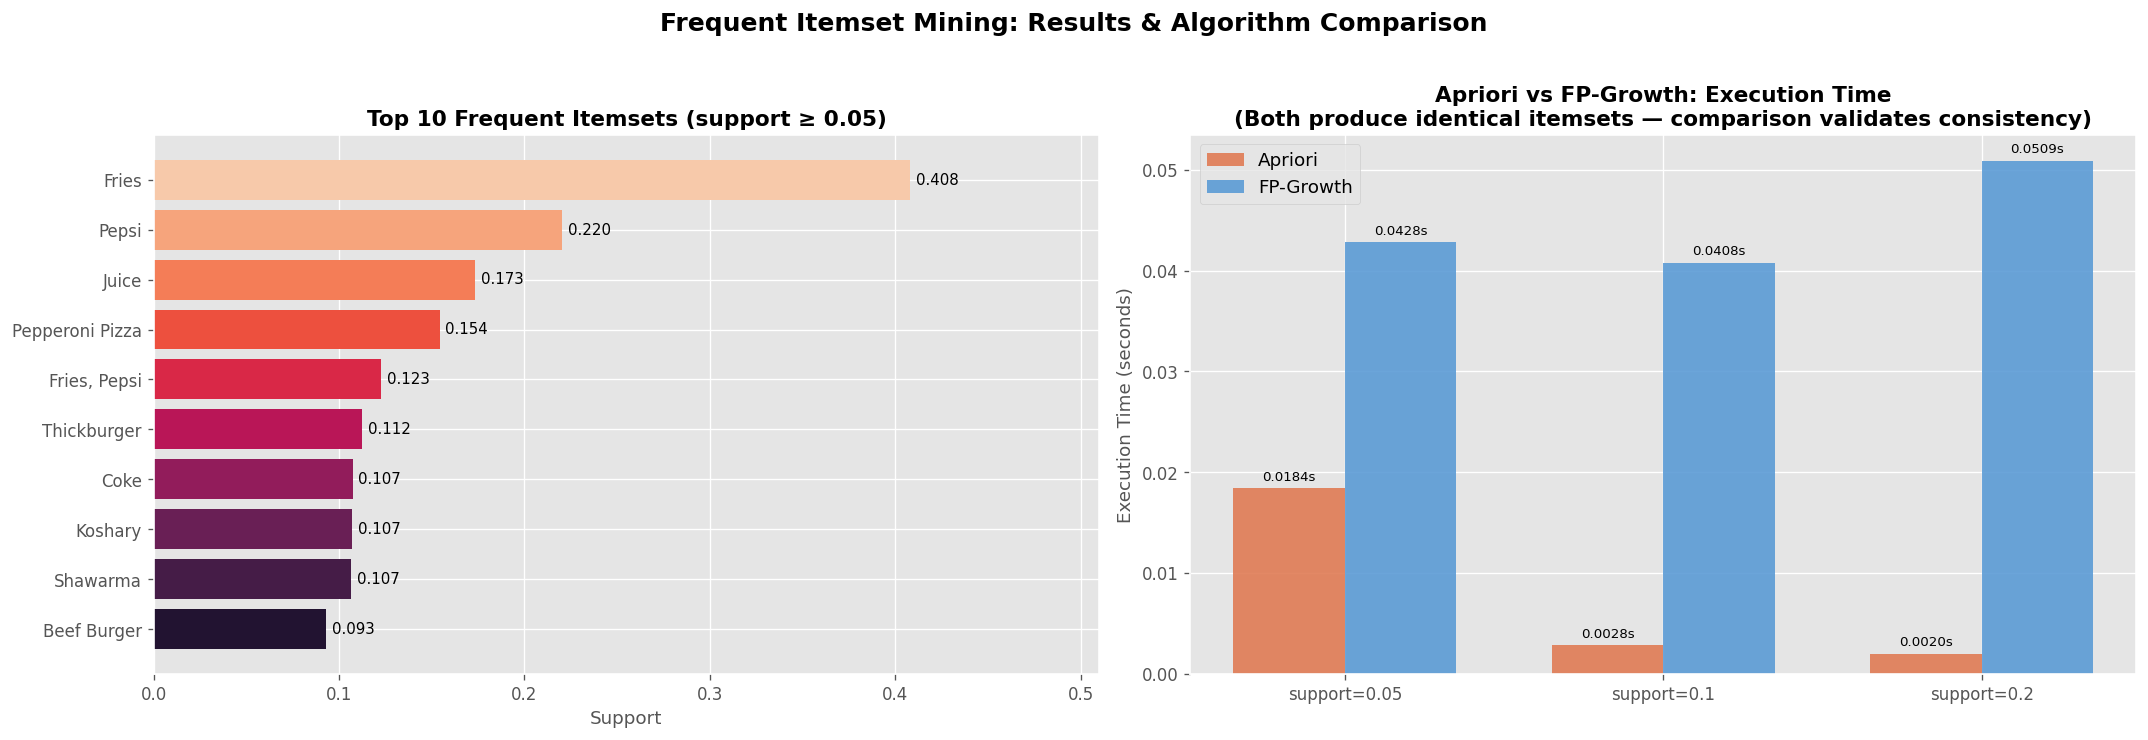

Saved: viz1_frequent_itemsets.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Left: Top 10 frequent itemsets (from best support) ---
ax = axes[0]
top10 = apriori_itemsets.sort_values('support', ascending=False).head(10).copy()
top10['label'] = top10['itemsets'].apply(lambda x: ', '.join(sorted(list(x))))
top10 = top10.sort_values('support', ascending=True)

colors = sns.color_palette('rocket', len(top10))
bars = ax.barh(top10['label'], top10['support'], color=colors)
for bar, val in zip(bars, top10['support']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_title(f'Top 10 Frequent Itemsets (support ≥ {BEST_SUPPORT})', fontsize=13, fontweight='bold')
ax.set_xlabel('Support', fontsize=11)
ax.set_xlim(0, top10['support'].max() * 1.25)

# --- Right: Execution time comparison across thresholds ---
ax2 = axes[1]
x = np.arange(len(THRESHOLDS))
w = 0.35
apriori_times = timing_df['Apriori (s)'].tolist()
fpg_times     = timing_df['FP-Growth (s)'].tolist()

b1 = ax2.bar(x - w/2, apriori_times, w, label='Apriori',   color='#E07B54', alpha=0.9)
b2 = ax2.bar(x + w/2, fpg_times,     w, label='FP-Growth', color='#5B9BD5', alpha=0.9)

for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
             f'{bar.get_height():.4f}s', ha='center', va='bottom', fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels([f'support={s}' for s in THRESHOLDS])
ax2.set_ylabel('Execution Time (seconds)', fontsize=11)
ax2.set_title('Apriori vs FP-Growth: Execution Time\n(Both produce identical itemsets — comparison validates consistency)',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)

plt.suptitle('Frequent Itemset Mining: Results & Algorithm Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz1_frequent_itemsets.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz1_frequent_itemsets.png')

---
## Visualization 2  Support vs Confidence (colored by Lift)

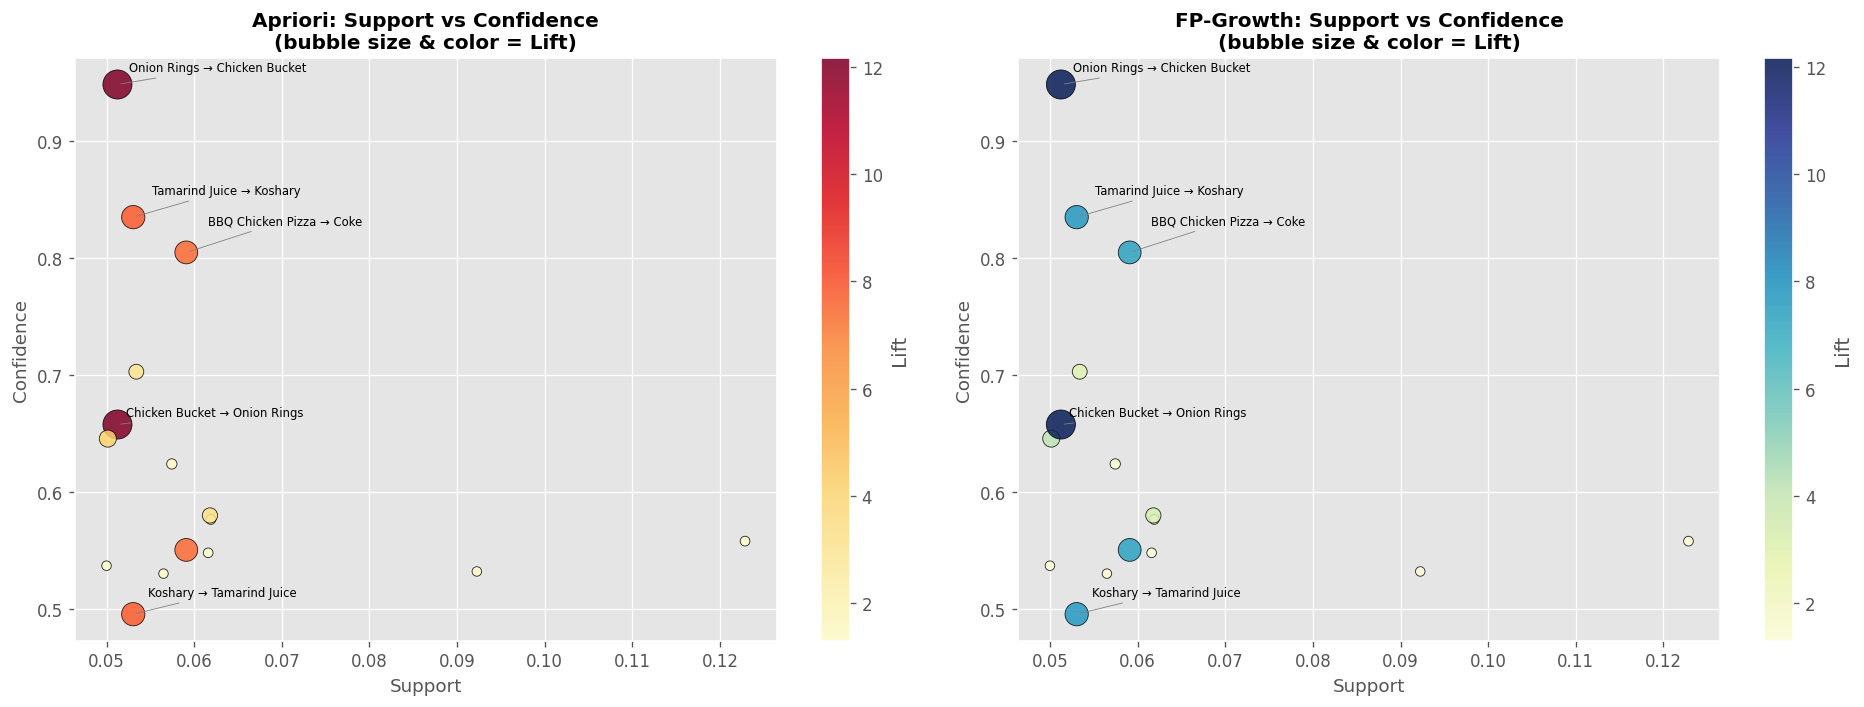

Saved: viz2_support_confidence.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, rules_df, title, cmap in zip(
    axes,
    [apriori_rules, fpg_rules],
    ['Apriori', 'FP-Growth'],
    ['YlOrRd', 'YlGnBu']
):
    sc = ax.scatter(
        rules_df['support'],
        rules_df['confidence'],
        c=rules_df['lift'],
        cmap=cmap,
        s=rules_df['lift'] * 25,
        alpha=0.85,
        edgecolors='black',
        linewidths=0.5
    )
    plt.colorbar(sc, ax=ax, label='Lift')

    # Annotate top 5 rules by lift (offset to avoid overlaps)
    for i, (_, row) in enumerate(rules_df.nlargest(5, 'lift').iterrows()):
        label = f"{', '.join(list(row['antecedents']))} → {', '.join(list(row['consequents']))}"
        ax.annotate(label, (row['support'], row['confidence']),
                    fontsize=7, ha='left',
                    xytext=(5 + i * 2, 5 + i * 3), textcoords='offset points',
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    ax.set_xlabel('Support', fontsize=11)
    ax.set_ylabel('Confidence', fontsize=11)
    ax.set_title(f'{title}: Support vs Confidence\n(bubble size & color = Lift)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz2_support_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz2_support_confidence.png')

---
## Visualization 3  Association Rules Network Graph (Top 10 Rules)

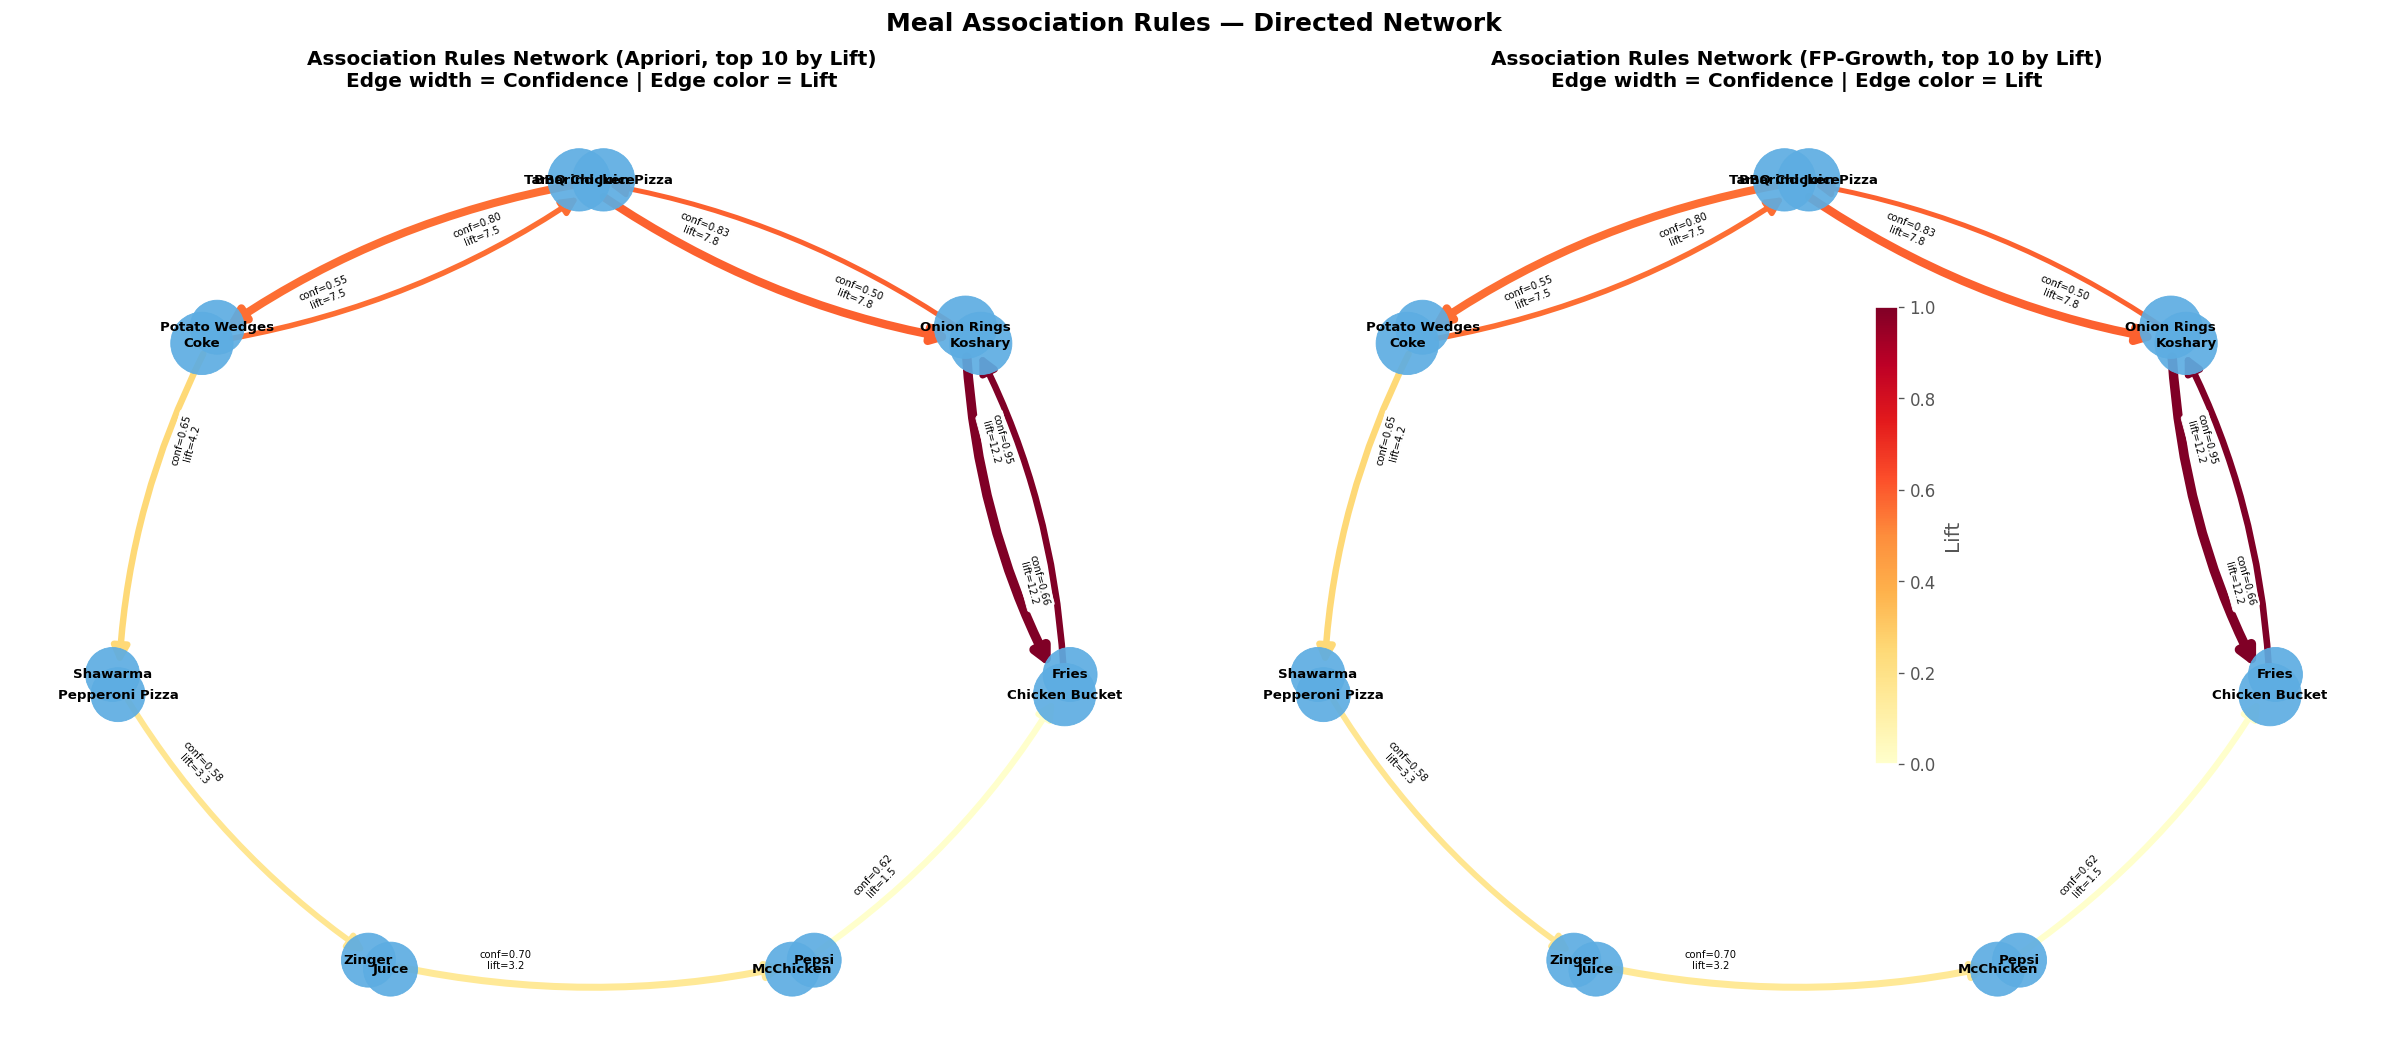

Saved: viz3_rules_network.png


In [7]:
def build_rules_graph(rules_df, top_n=10):
    top_rules = rules_df.nlargest(top_n, 'lift')
    G = nx.DiGraph()
    for _, row in top_rules.iterrows():
        ant = ', '.join(sorted(list(row['antecedents'])))
        con = ', '.join(sorted(list(row['consequents'])))
        G.add_edge(ant, con,
                   confidence=row['confidence'],
                   lift=row['lift'],
                   support=row['support'])
    return G, top_rules

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, rules_df, title in zip(axes, [apriori_rules, fpg_rules], ['Apriori', 'FP-Growth']):
    G, top_rules = build_rules_graph(rules_df, top_n=10)

    # Kamada-Kawai gives cleaner, less tangled layout than spring
    try:
        pos = nx.kamada_kawai_layout(G)
    except Exception:
        pos = nx.spring_layout(G, k=2.5, seed=42)

    node_degrees = dict(G.degree())
    node_sizes  = [700 + node_degrees[n] * 350 for n in G.nodes()]
    edge_widths = [G[u][v]['confidence'] * 6 for u, v in G.edges()]
    edge_lifts  = [G[u][v]['lift'] for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                           node_color='#5DADE2', alpha=0.92, ax=ax)
    edges_drawn = nx.draw_networkx_edges(
        G, pos, width=edge_widths,
        edge_color=edge_lifts, edge_cmap=plt.cm.YlOrRd,
        arrows=True, arrowsize=20, ax=ax,
        connectionstyle='arc3,rad=0.12',
        min_source_margin=18, min_target_margin=18
    )
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

    # Edge confidence labels
    edge_labels = {(u, v): f"conf={G[u][v]['confidence']:.2f}\nlift={G[u][v]['lift']:.1f}"
                   for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                  font_size=6, ax=ax, label_pos=0.3)

    ax.set_title(f'Association Rules Network ({title}, top 10 by Lift)\n'
                 'Edge width = Confidence | Edge color = Lift',
                 fontsize=12, fontweight='bold')
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd)
sm.set_array([])
plt.colorbar(sm, ax=axes, label='Lift', shrink=0.55, pad=0.02)
plt.suptitle('Meal Association Rules — Directed Network', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz3_rules_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz3_rules_network.png')

---
## Visualization 4  Association Rules Heatmap (Confidence Matrix)

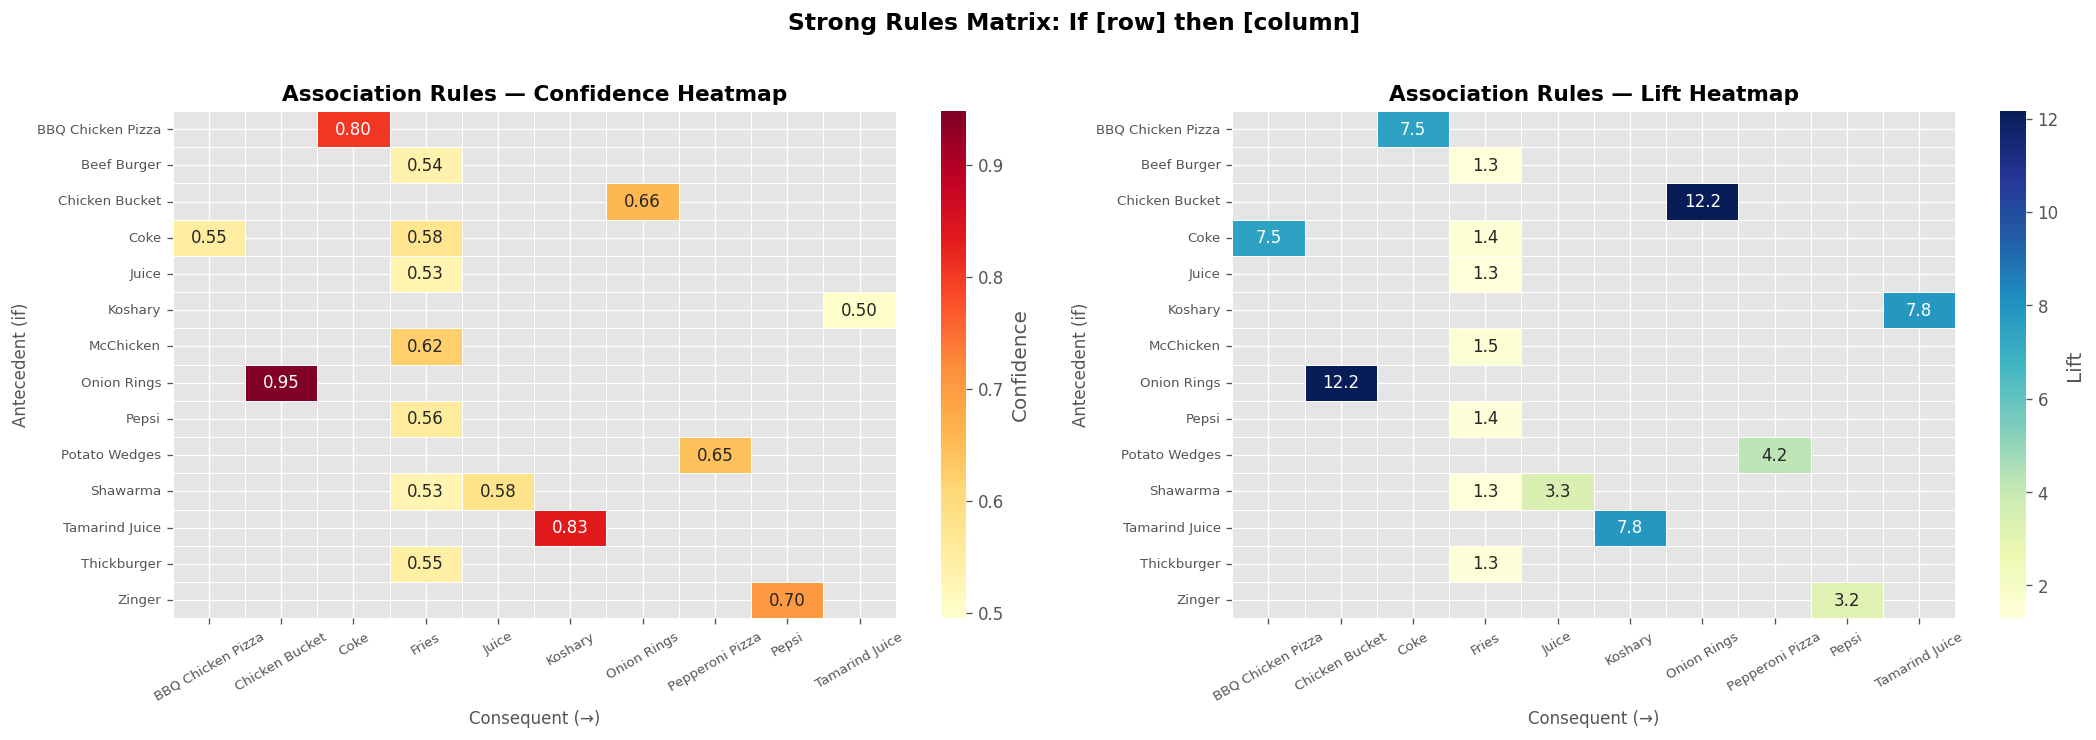

Saved: viz4_rules_heatmap.png


In [8]:
# Use Apriori rules (identical to FP-Growth, so one heatmap is sufficient)
rules_display = apriori_rules.copy()
rules_display['antecedent_str'] = rules_display['antecedents'].apply(
    lambda x: ', '.join(sorted(list(x)))
)
rules_display['consequent_str'] = rules_display['consequents'].apply(
    lambda x: ', '.join(sorted(list(x)))
)

# Pivot: rows=antecedent, cols=consequent, values=confidence
pivot_conf = rules_display.pivot_table(
    index='antecedent_str',
    columns='consequent_str',
    values='confidence',
    aggfunc='max'
)

# Pivot: same for lift
pivot_lift = rules_display.pivot_table(
    index='antecedent_str',
    columns='consequent_str',
    values='lift',
    aggfunc='max'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, pivot, title, cmap, fmt in zip(
    axes,
    [pivot_conf, pivot_lift],
    ['Confidence Heatmap', 'Lift Heatmap'],
    ['YlOrRd', 'YlGnBu'],
    ['.2f', '.1f']
):
    sns.heatmap(
        pivot,
        ax=ax,
        cmap=cmap,
        annot=True,
        fmt=fmt,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': title.split()[0]},
        mask=pivot.isna()
    )
    ax.set_title(f'Association Rules — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Consequent (→)', fontsize=10)
    ax.set_ylabel('Antecedent (if)', fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Strong Rules Matrix: If [row] then [column]', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz4_rules_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz4_rules_heatmap.png')

---
## Visualization 5  Top 15 Meals by PageRank Score

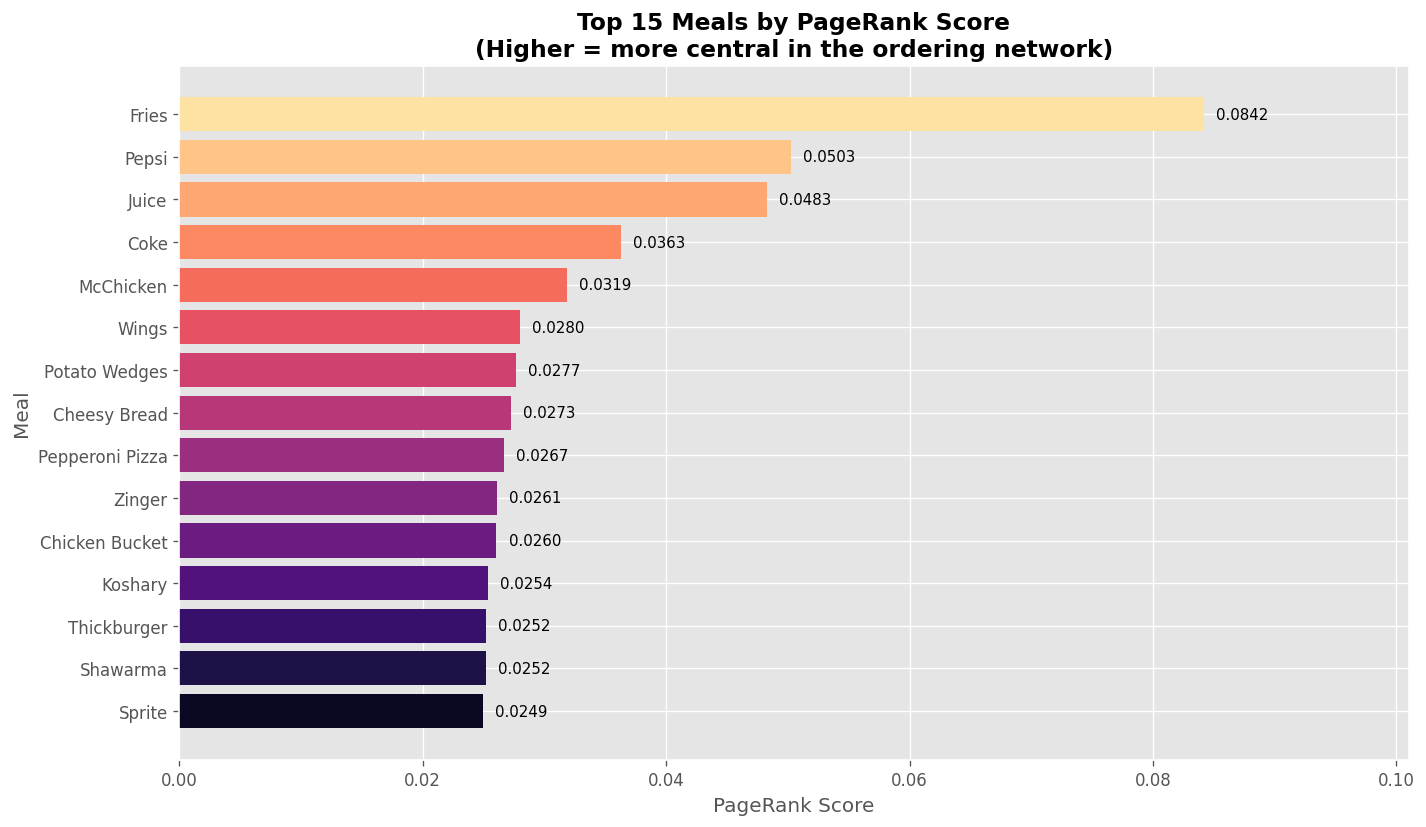

Saved: viz5_pagerank_bar.png


In [9]:
top15        = pr_df.head(15).copy()
top15_sorted = top15.sort_values('PageRank_Score', ascending=True)

colors = sns.color_palette('magma', len(top15_sorted))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15_sorted['Meal'], top15_sorted['PageRank_Score'], color=colors)

for bar, score in zip(bars, top15_sorted['PageRank_Score']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{score:.4f}', va='center', fontsize=9)

ax.set_title(
    'Top 15 Meals by PageRank Score\n'
    '(Higher = more central in the ordering network)',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('PageRank Score', fontsize=12)
ax.set_ylabel('Meal', fontsize=12)
ax.set_xlim(0, top15_sorted['PageRank_Score'].max() * 1.2)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz5_pagerank_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz5_pagerank_bar.png')

---
## Visualization 6  Meal Co-occurrence Network (PageRank-weighted)

Dynamic threshold (80th percentile): 212
Nodes in subgraph: 42, Edges: 175


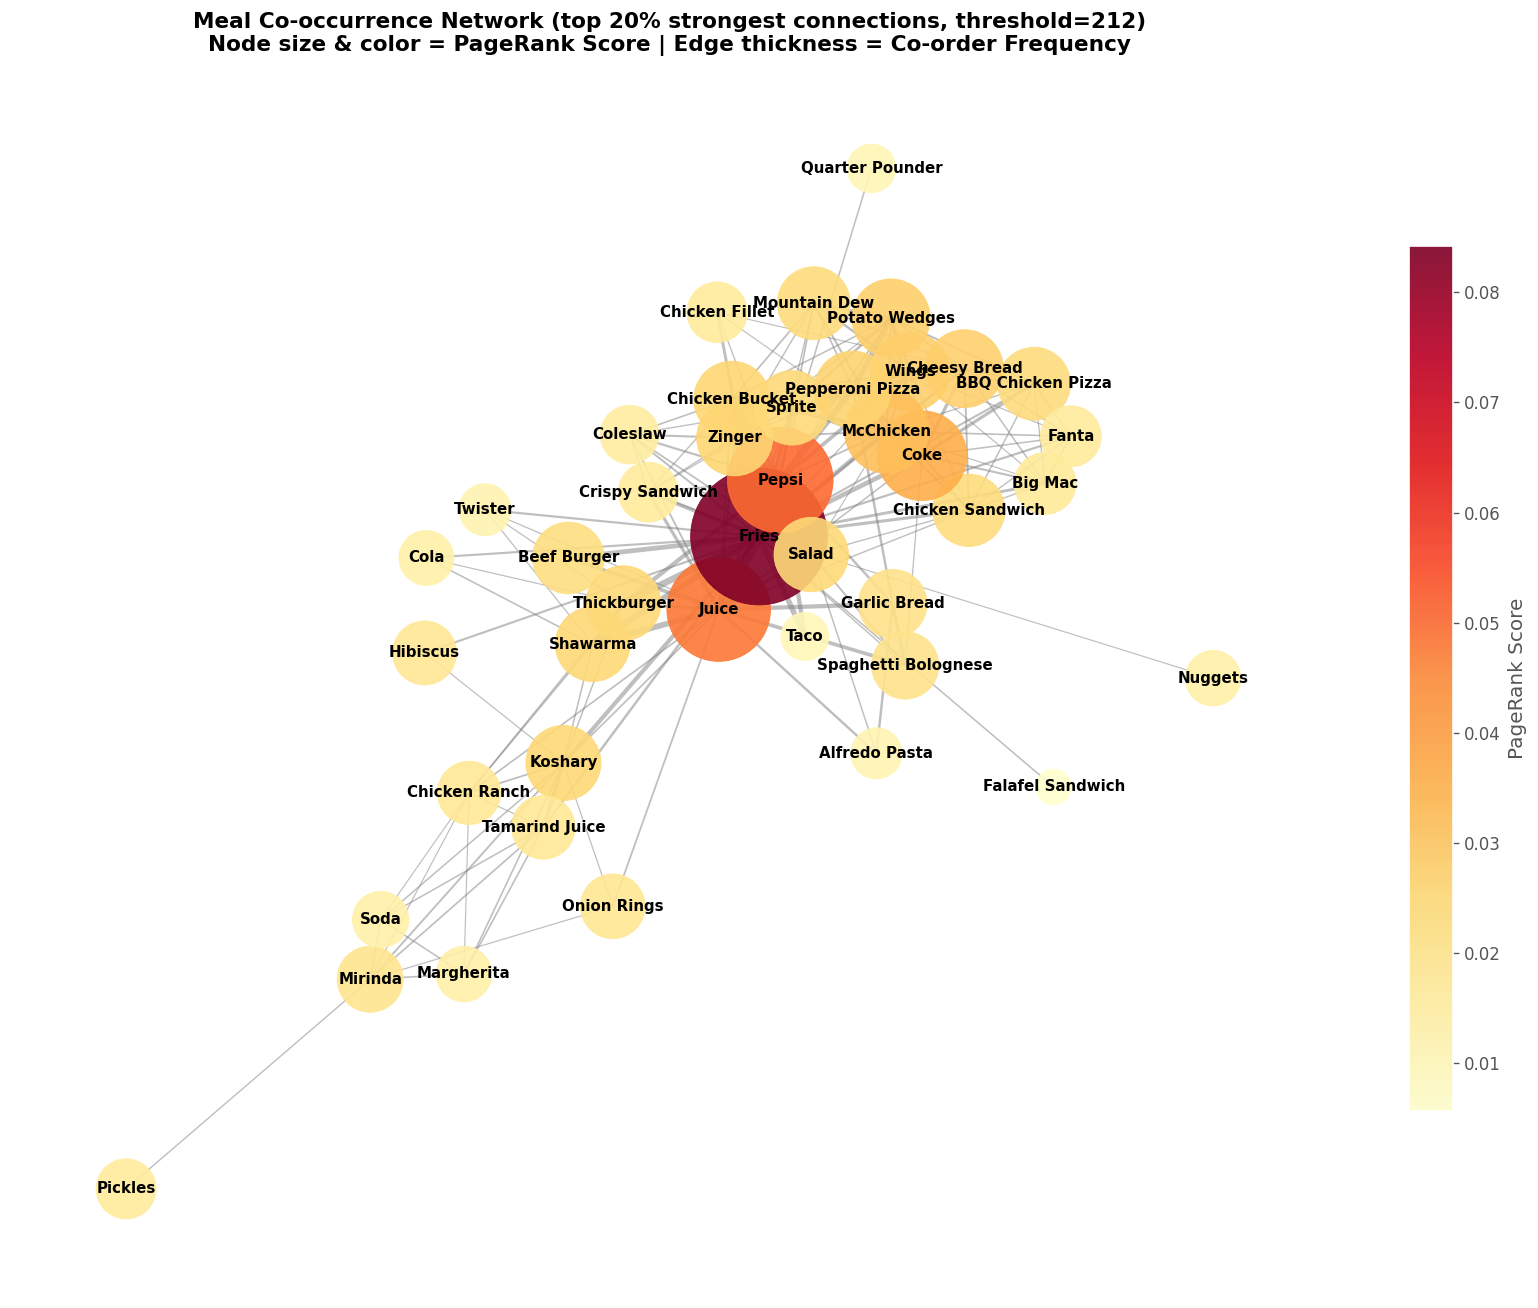

Saved: viz6_cooccurrence_network.png


In [10]:
all_weights = [d['weight'] for _, _, d in G_meal.edges(data=True)]
EDGE_THRESHOLD = int(np.percentile(all_weights, 80))

sub_G = nx.Graph()
for u, v, d in G_meal.edges(data=True):
    if d['weight'] > EDGE_THRESHOLD:
        sub_G.add_edge(u, v, weight=d['weight'])

print(f'Dynamic threshold (80th percentile): {EDGE_THRESHOLD}')
print(f'Nodes in subgraph: {sub_G.number_of_nodes()}, Edges: {sub_G.number_of_edges()}')

pos = nx.spring_layout(sub_G, k=1.2, seed=42)

node_sizes  = [pagerank_scores.get(n, 0.01) * 80000 for n in sub_G.nodes()]
node_colors = [pagerank_scores.get(n, 0) for n in sub_G.nodes()]
edge_widths = [sub_G[u][v]['weight'] / max(all_weights) * 8 for u, v in sub_G.edges()]

fig, ax = plt.subplots(figsize=(14, 11))

nodes = nx.draw_networkx_nodes(
    sub_G, pos, node_size=node_sizes,
    node_color=node_colors, cmap=plt.cm.YlOrRd, alpha=0.9, ax=ax
)
nx.draw_networkx_edges(
    sub_G, pos, width=edge_widths,
    edge_color='gray', alpha=0.5, ax=ax
)
nx.draw_networkx_labels(
    sub_G, pos, font_size=9, font_weight='bold', ax=ax
)

plt.colorbar(nodes, ax=ax, label='PageRank Score', shrink=0.7)
ax.set_title(
    f'Meal Co-occurrence Network (top 20% strongest connections, threshold={EDGE_THRESHOLD})\n'
    'Node size & color = PageRank Score | Edge thickness = Co-order Frequency',
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz6_cooccurrence_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz6_cooccurrence_network.png')

---
## Key Insights (dynamically generated)

In [11]:
top_rule       = apriori_rules.nlargest(1, 'lift').iloc[0]
top_rule_ant   = ', '.join(list(top_rule['antecedents']))
top_rule_con   = ', '.join(list(top_rule['consequents']))
second_rule    = apriori_rules.nlargest(2, 'lift').iloc[1]
sec_ant        = ', '.join(list(second_rule['antecedents']))
sec_con        = ', '.join(list(second_rule['consequents']))

avg_apriori = timing_df['Apriori (s)'].mean()
avg_fpg     = timing_df['FP-Growth (s)'].mean()
if avg_apriori < avg_fpg:
    faster_algo  = 'Apriori'
    slower_algo  = 'FP-Growth'
    speed_factor = avg_fpg / avg_apriori
else:
    faster_algo  = 'FP-Growth'
    slower_algo  = 'Apriori'
    speed_factor = avg_apriori / avg_fpg

print('=' * 65)
print('KEY INSIGHTS')
print('=' * 65)
print(f"\n1. TOP PAGERANK MEAL: '{top_meal}' (score={top_meal_score:.4f})")
print(f"   Most central meal in the ordering network — appears across")
print(f"   all restaurants and meal categories.")

print(f"\n2. STRONGEST RULE: '{top_rule_ant}' → '{top_rule_con}'")
print(f"   Confidence={top_rule['confidence']:.3f}, Lift={top_rule['lift']:.2f}")
print(f"   {top_rule['confidence']*100:.0f}% of '{top_rule_ant}' orders also include '{top_rule_con}'.")

print(f"\n3. SECOND STRONGEST RULE: '{sec_ant}' → '{sec_con}'")
print(f"   Confidence={second_rule['confidence']:.3f}, Lift={second_rule['lift']:.2f}")
print(f"   Note: Rules 2 & 3 are bidirectional, confirming a strong pair.")

print(f"\n4. ALGORITHM SPEED: {faster_algo} is {speed_factor:.1f}x faster than {slower_algo}.")
print(f"   Both produce identical rules — validates consistency across algorithms.")

print(f"\n5. GRAPH STRUCTURE: {G_meal.number_of_nodes()} meals, {G_meal.number_of_edges()} co-occurrence pairs.")
print(f"   Density={nx.density(G_meal):.3f} — the meal ordering network is highly connected.")
print('=' * 65)

KEY INSIGHTS

1. TOP PAGERANK MEAL: 'Fries' (score=0.0842)
   Most central meal in the ordering network — appears across
   all restaurants and meal categories.

2. STRONGEST RULE: 'Chicken Bucket' → 'Onion Rings'
   Confidence=0.657, Lift=12.16
   66% of 'Chicken Bucket' orders also include 'Onion Rings'.

3. SECOND STRONGEST RULE: 'Onion Rings' → 'Chicken Bucket'
   Confidence=0.948, Lift=12.16
   Note: Rules 2 & 3 are bidirectional, confirming a strong pair.

4. ALGORITHM SPEED: Apriori is 5.8x faster than FP-Growth.
   Both produce identical rules — validates consistency across algorithms.

5. GRAPH STRUCTURE: 46 meals, 886 co-occurrence pairs.
   Density=0.856 — the meal ordering network is highly connected.
